# 08 · Clustering Visualisation and Results

**Loads cluster maps saved by notebook 07 — no reclustering.**

**Produces:**
- Fig 1 · Ward dendrogram for best representative draw (both cut lines)
- Fig 2 · S matrix heatmaps: flat vs depth-3 vs depth-4
- Fig 3 · Mean hourly load profile per cluster (best draw)
- Table 1 · Reconciliation improvement by hierarchy depth
- Fig 4 · MAE improvement bar chart with paper target lines
- Fig 5 · RQ1: Ward vs Random — does clustering method matter?
- Fig 6 · MAAdj ranked plot (paper Fig 5 equivalent)

**Run order:** 07 must be run first.

In [16]:
import sys, os, json
_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root,'config')) and os.path.isdir(os.path.join(_root,'utils')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root); os.chdir(_root)

from config.settings import cfg, DATASET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.preprocessing import StandardScaler
sns.set_style('whitegrid')
plt.rcParams.update({'font.size':11, 'figure.dpi':120})

out_dir = os.path.join(_root, cfg['OUTPUT_DIR'])
fig_dir = os.path.join(_root, 'results', 'figures')
rep_dir = os.path.join(_root, 'results', 'reports')
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(rep_dir, exist_ok=True)

ID  = cfg['ID_COL']
KWH = cfg['DEMAND_COL']
print(f'Dataset : {DATASET.upper()}')
ID_COL       = cfg['ID_COL']                         # 'LCLid'
DEMAND_COL   = cfg['DEMAND_COL']                     # 'kWh'
OUTPUT_DIR   = os.path.join(_root, cfg['OUTPUT_DIR'])  # 'data/output_lcl/'
SAMPLE_SIZE  = cfg['SAMPLE_SIZE']
N_DRAWS      = cfg['N_DRAWS']
TRAIN_MONTHS = cfg['TRAIN_MONTHS']
VAL_MONTHS   = cfg['VAL_MONTHS']

Dataset : LCL


## Load cluster maps from notebook 07

In [17]:
cluster_path = os.path.join(out_dir, f'cluster_maps_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.json')
assert os.path.exists(cluster_path), \
    f'cluster_maps_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.json not found — run notebook 07 first.'

with open(cluster_path) as f:
    cluster_data = json.load(f)

fine_maps          = {int(k): v for k, v in cluster_data['fine_maps'].items()}
coarse_maps        = {int(k): v for k, v in cluster_data['coarse_maps'].items()}
rand_maps          = {int(k): v for k, v in cluster_data['rand_maps'].items()}
kmeans_fine_maps   = {int(k): v for k, v in cluster_data.get('kmeans_fine_maps', {}).items()}
kmeans_coarse_maps = {int(k): v for k, v in cluster_data.get('kmeans_coarse_maps', {}).items()}
k_fines            = {int(k): v for k, v in cluster_data['k_fine'].items()}
k_coarses          = {int(k): v for k, v in cluster_data['k_coarse'].items()}
units_draws        = {int(k): v for k, v in cluster_data['units_per_draw'].items()}
best_draw          = int(cluster_data['best_draw'])
meta               = cluster_data['metadata']

print(f'Cluster maps loaded for {len(fine_maps)} draws')
print(f'  Ward maps   : fine={len(fine_maps)}  coarse={len(coarse_maps)}  rand={len(rand_maps)}')
print(f'  K-means maps: fine={len(kmeans_fine_maps)}  coarse={len(kmeans_coarse_maps)}')
print(f'Best draw for visualisation : {best_draw}')
print(f'  K fine   : {k_fines[best_draw]}')
print(f'  K coarse : {k_coarses[best_draw]}')
print(f'  Units    : {len(units_draws[best_draw])}')
print(f'\nMetadata:')
for k, v in meta.items():
    print(f'  {k:30} : {v}')

Cluster maps loaded for 10 draws
  Ward maps   : fine=10  coarse=10  rand=10
  K-means maps: fine=10  coarse=10
Best draw for visualisation : 7
  K fine   : 4
  K coarse : 2
  Units    : 20

Metadata:
  dataset                        : lcl
  random_seed                    : 42
  n_draws                        : 10
  sample_size                    : 50
  k_method                       : natural elbow — second difference of Ward linkage distances
  k_fine_range                   : 2 to 8
  k_coarse_formula               : max(2, k_fine // 2)
  kmeans_k                       : same k_fine and k_coarse as Ward per draw
  random_k_matches               : k_fine per draw (same number of groups)
  ward_features                  : tsfeatures extracted from training period only
  units_available                : 192
  mint_formula                   : W_full = S @ Wb @ S.T  (structural WLS)
  w_source                       : val period residual variances (no test data leakage)


## Load forecasts and metrics

In [18]:
ind          = pd.read_parquet(os.path.join(out_dir, f'forecasts_individual_{DATASET}.parquet'))
agg          = pd.read_parquet(os.path.join(out_dir, f'forecasts_aggregate_{DATASET}.parquet'))
tsf          = pd.read_parquet(os.path.join(out_dir, f'tsf_features_{DATASET}.parquet'))
metrics_flat = pd.read_parquet(os.path.join(out_dir, f'metrics_flat_{DATASET}.parquet'))
metrics_struct = pd.read_parquet(os.path.join(out_dir, f'metrics_structured_{DATASET}.parquet'))
maadj_df     = pd.read_parquet(os.path.join(out_dir, f'maadj_store_{DATASET}.parquet'))

tsf[ID] = tsf[ID].astype(str)
tsf      = tsf.set_index(ID)

metrics_all_raw = pd.concat([metrics_flat, metrics_struct], ignore_index=True)

base_mae = (
    metrics_all_raw[metrics_all_raw['level'] == 'aggregate']
    .groupby('model')['mae_base']
    .mean()
)

# Mean aggregate demand should be per-draw sample size, not full dataset
# Compute from the individual forecast file (unit-level y_true summed per draw/timestamp)
with open(os.path.join(out_dir, f'mean_agg_demand_{DATASET}.json')) as f:
    _d = json.load(f)
mean_agg_demand = _d['mean']
print(f'Mean aggregate demand (reconciliation draws): {mean_agg_demand:.3f} {KWH}')

print(f'Base aggregate MAE: LGBM={base_mae.get("LGBM",float("nan")):.4f}  '
      f'LR={base_mae.get("LR",float("nan")):.4f}')
print(f'Mean aggregate demand : {mean_agg_demand:.3f} {KWH}')
print(f'maadj_df shape        : {maadj_df.shape}')
print(f'Cluster methods       : {sorted(maadj_df["cluster_method"].unique())}')

Mean aggregate demand (reconciliation draws): 8.046 kWh
Base aggregate MAE: LGBM=1.4365  LR=1.5004
Mean aggregate demand : 8.046 kWh
maadj_df shape        : (4800, 6)
Cluster methods       : ['flat', 'kmeans_depth3', 'kmeans_depth4', 'random', 'ward_depth3', 'ward_depth4']


In [19]:
print(agg.groupby('draw')['y_true'].count().describe())  # nb08's source
print(metrics_flat[metrics_flat['level']=='aggregate']['mae_base'].describe())  # nb07's source

count       30.0
mean     16960.0
std          0.0
min      16960.0
25%      16960.0
50%      16960.0
75%      16960.0
max      16960.0
Name: y_true, dtype: float64
count    4.000000
mean     1.468450
std      0.036893
min      1.436500
25%      1.436500
50%      1.468450
75%      1.500400
max      1.500400
Name: mae_base, dtype: float64


## Rebuild dendrogram for best draw (for plotting only)

In [20]:
# Rebuild Z for best_draw — needed for dendrogram plot
# Uses same StandardScaler + tsfeatures as notebook 07
draw_units = units_draws[best_draw]
scaler     = StandardScaler()
tsf_draw   = tsf.reindex(draw_units).fillna(0)
X_draw     = scaler.fit_transform(tsf_draw.values)
Z_draw     = linkage(X_draw, method='ward')

k_fine   = k_fines[best_draw]
k_coarse = k_coarses[best_draw]
fine_map  = fine_maps[best_draw]
coarse_map = coarse_maps[best_draw]

# Cut heights
h_fine   = Z_draw[-(k_fine-1),   2] + 0.01
h_coarse = Z_draw[-(k_coarse-1), 2] + 0.01 if k_coarse >= 2 else None

# Verify labels match saved maps
fine_check = fcluster(Z_draw, t=k_fine, criterion='maxclust')
saved_fine = np.array([fine_maps[best_draw][u]+1 for u in draw_units])
# Note: fcluster may permute label integers but cluster membership is same
print(f'Best draw   : {best_draw}')
print(f'K fine      : {k_fine}')
print(f'K coarse    : {k_coarse}')
sizes = np.bincount(fine_check)[1:]
print(f'Cluster sizes (fine): {sorted(sizes.tolist(), reverse=True)}')

Best draw   : 7
K fine      : 4
K coarse    : 2
Cluster sizes (fine): [8, 5, 4, 3]


## Figure 1 — Ward dendrogram

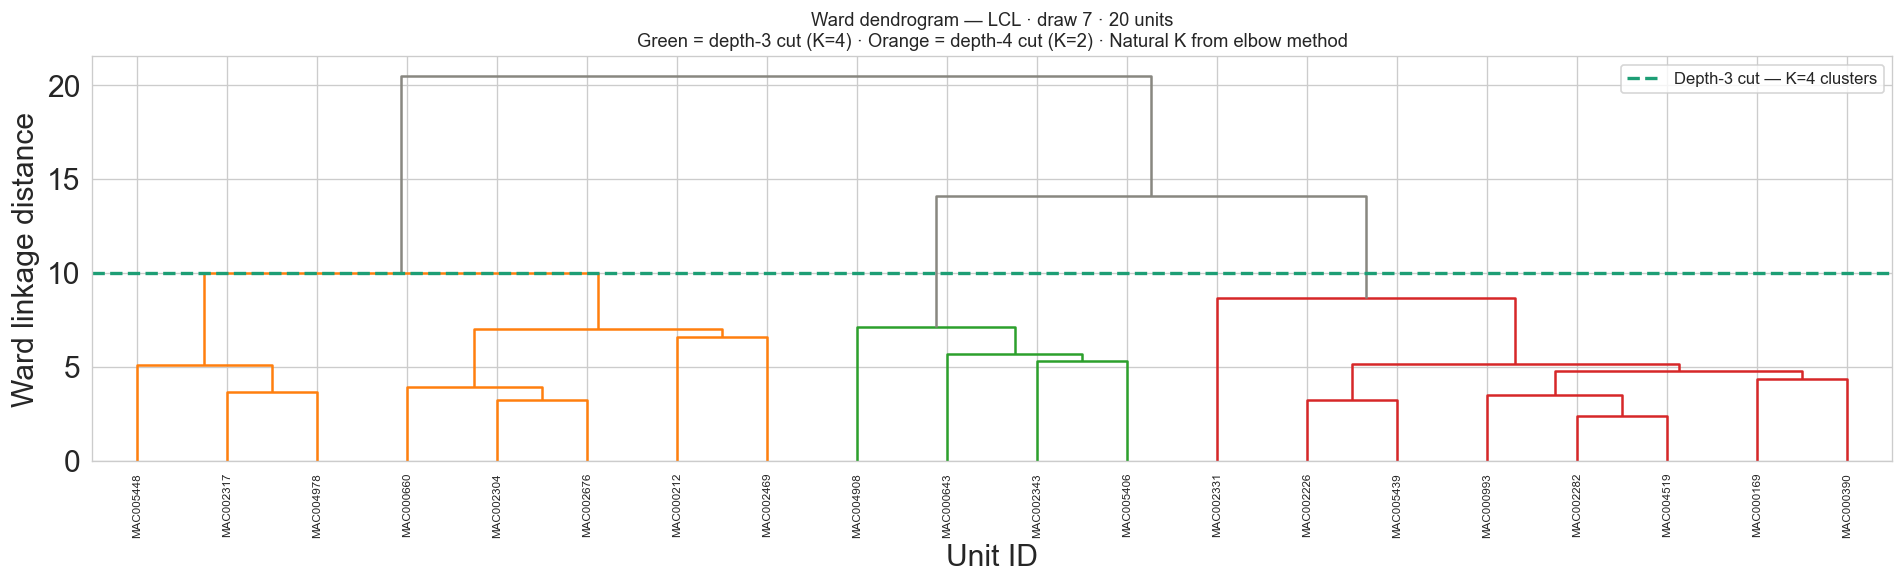

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_dendrogram_lcl.png


In [21]:
CLUSTER_COLORS = ['#185FA5','#1D9E75','#EF9F27','#D85A30','#534AB7',
                  '#888780','#E24B4A','#0F6E56']

fig, ax = plt.subplots(figsize=(16, 5))

dendrogram(
    Z_draw,
    labels=[str(u) for u in draw_units],
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=h_fine,
    above_threshold_color='#888780'
)

ax.axhline(h_fine, color='#1D9E75', linewidth=2, linestyle='--',
           label=f'Depth-3 cut — K={k_fine} clusters')
if h_coarse and h_coarse < h_fine:
    ax.axhline(h_coarse, color='#EF9F27', linewidth=2, linestyle='--',
               label=f'Depth-4 cut — K={k_coarse} super-clusters')

ax.set_title(
    f'Ward dendrogram — {DATASET.upper()} · draw {best_draw} · '
    f'{len(draw_units)} units\n'
    f'Green = depth-3 cut (K={k_fine}) · '
    f'Orange = depth-4 cut (K={k_coarse}) · '
    f'Natural K from elbow method', fontsize=11
)
ax.set_xlabel('Unit ID')
ax.set_ylabel('Ward linkage distance')
ax.legend(fontsize=10)
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_dendrogram_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')

## Figure 2 — S matrix heatmaps

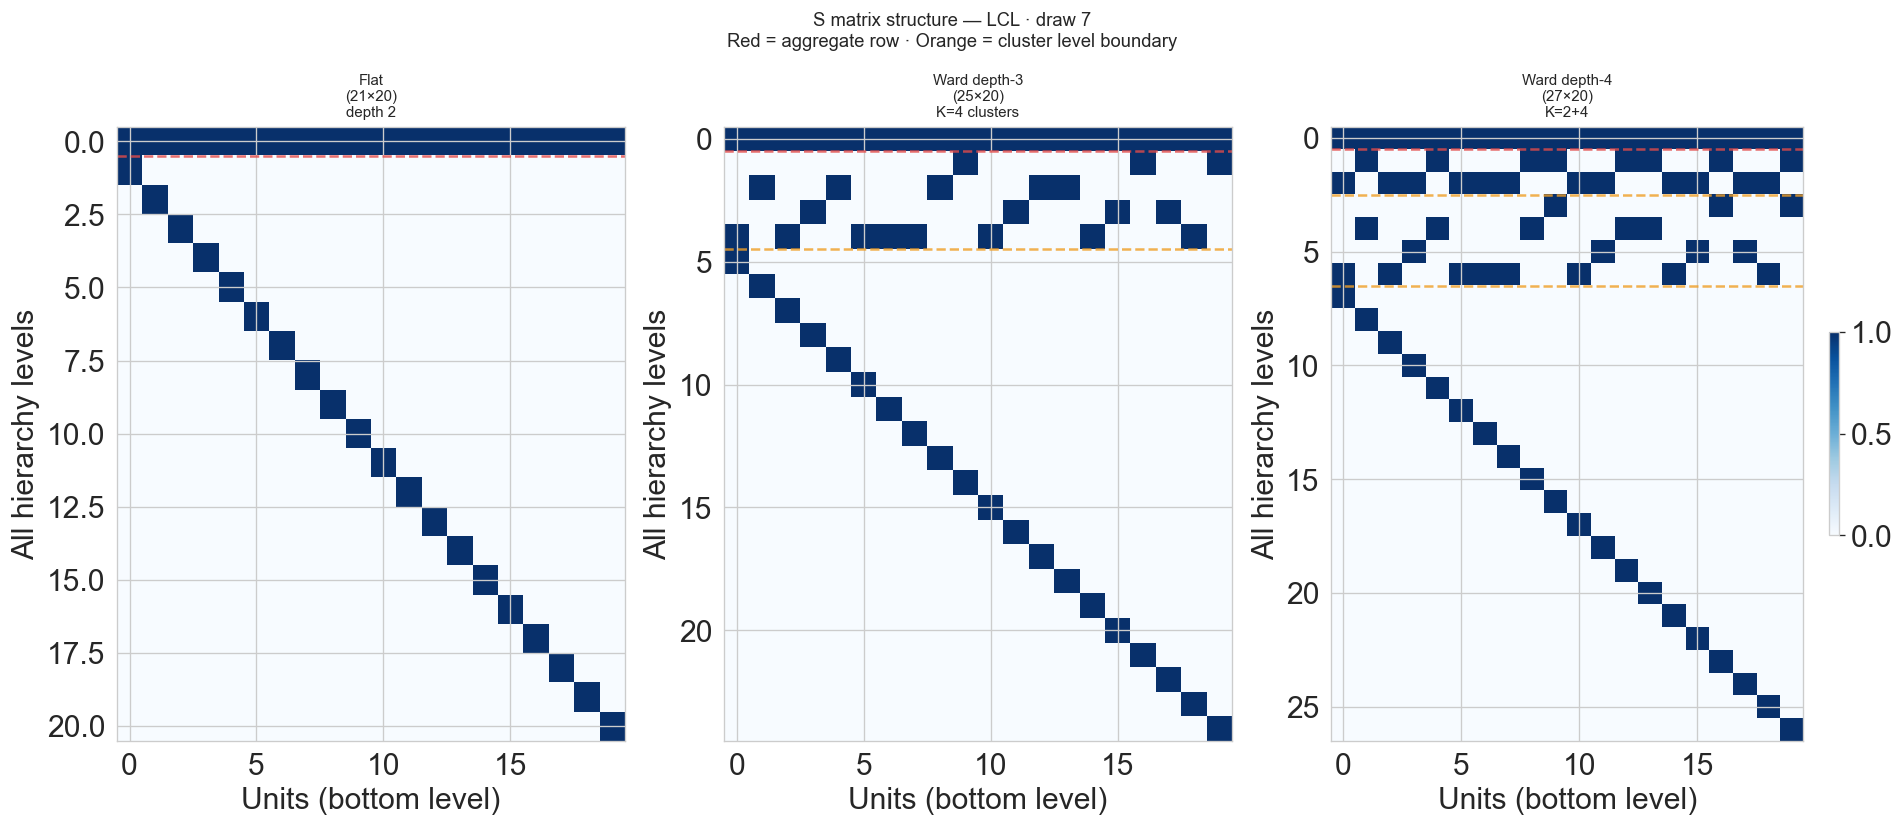

Flat S: (21, 20)  Depth-3: (25, 20)  Depth-4: (27, 20)
Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_s_matrix_lcl.png


In [22]:
def build_S_flat(units):
    n = len(units)
    return np.vstack([np.ones((1,n)), np.eye(n)])

def build_S_depth3(units, cluster_map):
    n = len(units)
    clusters = sorted(set(cluster_map[u] for u in units))
    cl = np.zeros((len(clusters), n))
    for ci,c in enumerate(clusters):
        for ui,u in enumerate(units):
            if cluster_map[u]==c: cl[ci,ui]=1
    return np.vstack([np.ones((1,n)), cl, np.eye(n)])

def build_S_depth4(units, coarse_map, fine_map):
    n = len(units)
    cc = sorted(set(coarse_map[u] for u in units))
    fc = sorted(set(fine_map[u]   for u in units))
    cr = np.zeros((len(cc),n)); fr = np.zeros((len(fc),n))
    for ci,c in enumerate(cc):
        for ui,u in enumerate(units):
            if coarse_map[u]==c: cr[ci,ui]=1
    for fi,f in enumerate(fc):
        for ui,u in enumerate(units):
            if fine_map[u]==f: fr[fi,ui]=1
    return np.vstack([np.ones((1,n)), cr, fr, np.eye(n)])

S_flat = build_S_flat(draw_units)
S_d3   = build_S_depth3(draw_units, fine_map)
S_d4   = build_S_depth4(draw_units, coarse_map, fine_map)

fig, axes = plt.subplots(1, 3, figsize=(16, 7))
configs = [
    (S_flat, f'Flat\n({S_flat.shape[0]}×{S_flat.shape[1]})\ndepth 2', []),
    (S_d3,   f'Ward depth-3\n({S_d3.shape[0]}×{S_d3.shape[1]})\nK={k_fine} clusters', [k_fine]),
    (S_d4,   f'Ward depth-4\n({S_d4.shape[0]}×{S_d4.shape[1]})\nK={k_coarse}+{k_fine}', [k_coarse, k_coarse+k_fine]),
]
for ax, (S, title, dividers) in zip(axes, configs):
    im = ax.imshow(S, aspect='auto', cmap='Blues',
                   interpolation='nearest', vmin=0, vmax=1)
    ax.axhline(0.5, color='#E24B4A', linewidth=1.5, linestyle='--', alpha=0.8)
    for d in dividers:
        ax.axhline(d+0.5, color='#EF9F27', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Units (bottom level)')
    ax.set_ylabel('All hierarchy levels')

plt.colorbar(im, ax=axes[-1], fraction=0.02)
plt.suptitle(
    f'S matrix structure — {DATASET.upper()} · draw {best_draw}\n'
    f'Red = aggregate row · Orange = cluster level boundary',
    fontsize=11
)
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_s_matrix_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Flat S: {S_flat.shape}  Depth-3: {S_d3.shape}  Depth-4: {S_d4.shape}')
print(f'Saved -> {path}')

## Figure 3 — Mean hourly load profile per cluster

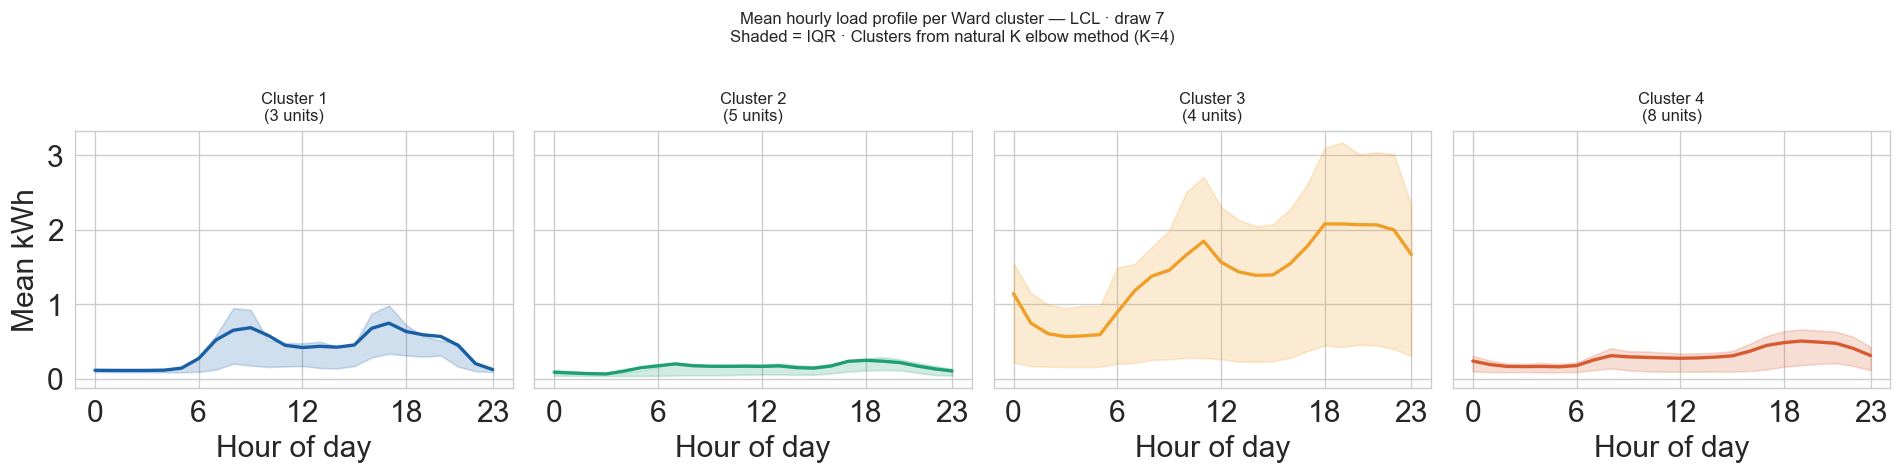

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_cluster_profiles_lcl.png


In [23]:
df_feat = pd.read_parquet(os.path.join(out_dir, f'df_features_{DATASET}.parquet'))
df_feat['timestamp'] = pd.to_datetime(df_feat['timestamp'])

if 'hour' not in df_feat.columns:
    df_feat['hour'] = df_feat['timestamp'].dt.hour

# Add cluster labels for best draw
cluster_df = pd.DataFrame({
    ID:             draw_units,
    'fine_cluster': [fine_map[u] for u in draw_units]
})
df_draw = (
    df_feat[df_feat[ID].isin(draw_units)]
    .merge(cluster_df, on=ID, how='left')
)

n_clusters = k_fine
fig, axes = plt.subplots(1, n_clusters,
                          figsize=(4*n_clusters, 4), sharey=True)
if n_clusters == 1: axes = [axes]

for ax, c in zip(axes, range(n_clusters)):
    sub     = df_draw[df_draw['fine_cluster'] == c]
    n_units = sub[ID].nunique()
    hourly  = sub.groupby('hour')[KWH]
    mean_h  = hourly.mean()
    q25_h   = hourly.quantile(0.25)
    q75_h   = hourly.quantile(0.75)
    color   = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]

    ax.plot(mean_h.index, mean_h.values, color=color, linewidth=2)
    ax.fill_between(mean_h.index, q25_h, q75_h,
                    alpha=0.2, color=color)
    ax.set_title(f'Cluster {c+1}\n({n_units} units)', fontsize=10)
    ax.set_xlabel('Hour of day')
    if ax == axes[0]: ax.set_ylabel(f'Mean {KWH}')
    ax.set_xticks([0, 6, 12, 18, 23])

plt.suptitle(
    f'Mean hourly load profile per Ward cluster — {DATASET.upper()} · draw {best_draw}\n'
    f'Shaded = IQR · Clusters from natural K elbow method (K={k_fine})\n',
   # f'Cluster maps saved by notebook 07 — no reclustering here',
    fontsize=10
)
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_cluster_profiles_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')

## Table 1 — Reconciliation improvement by hierarchy depth

In [24]:
all_m = pd.concat([metrics_flat, metrics_struct], ignore_index=True)

METHOD_LABELS = {
    'flat':        'Flat (depth 2)',
    'ward_depth3': 'Ward depth-3',
    'ward_depth4': 'Ward depth-4',
    'random':      'Random (depth 3)',
}
DEPTHS = {'flat':2, 'ward_depth3':3, 'ward_depth4':4, 'random':3}

rows = []
for method in ['flat','ward_depth3','ward_depth4','random']:
    for approach in ['local','global']:
        sa = all_m[
            (all_m['cluster_method']==method) &
            (all_m['level']         =='aggregate') &
            (all_m['approach']      ==approach) &
            (all_m['model']         =='LGBM')
        ]
        sb = all_m[
            (all_m['cluster_method']==method) &
            (all_m['level']         =='unit') &
            (all_m['approach']      ==approach) &
            (all_m['model']         =='LGBM')
        ]
        if len(sa) == 0: continue
        sa = sa.iloc[0]
        sb = sb.iloc[0] if len(sb)>0 else None
        base = float(base_mae.get('LGBM', sa['mae_base']))
        rows.append({
            'Hierarchy':       METHOD_LABELS[method],
            'Approach':        approach,
            'Depth':           DEPTHS[method],
            'Agg MAE before':  round(base, 3),
            'Agg MAE after':   round(sa['mae_rec'], 3),
            'NMAE% after':     round(sa['mae_rec']/mean_agg_demand*100, 1),
            'Improvement%':    round((base-sa['mae_rec'])/base*100, 1),
            'Bldg MAE before': round(sb['mae_base'],3) if sb is not None else float('nan'),
            'Bldg MAE after':  round(sb['mae_rec'], 3) if sb is not None else float('nan'),
            'MAAdj':           round(sa['maa'], 4),
        })

table1 = pd.DataFrame(rows)
print(f'TABLE 1 — Reconciliation by hierarchy depth')
print(f'Dataset: {DATASET.upper()} · LGBM · mean agg demand: {mean_agg_demand:.3f} {KWH}')
print(f'Natural K (draw {best_draw}): K_fine={k_fines[best_draw]}, K_coarse={k_coarses[best_draw]}')
print(f'Positive Improvement% = aggregate MAE improved\n')
print(table1.to_string(index=False))

table1.to_csv(os.path.join(rep_dir, f'table1_{DATASET}.csv'), index=False)
print(f'\nSaved -> table1_{DATASET}.csv')

TABLE 1 — Reconciliation by hierarchy depth
Dataset: LCL · LGBM · mean agg demand: 8.046 kWh
Natural K (draw 7): K_fine=4, K_coarse=2
Positive Improvement% = aggregate MAE improved

       Hierarchy Approach  Depth  Agg MAE before  Agg MAE after  NMAE% after  Improvement%  Bldg MAE before  Bldg MAE after  MAAdj
  Flat (depth 2)    local      2           1.436          1.432         17.8           0.3            0.214           0.216 0.0269
  Flat (depth 2)   global      2           1.436          1.433         17.8           0.2            0.215           0.217 0.0283
    Ward depth-3    local      3           1.436          1.420         17.7           1.1            0.214           0.216 0.1476
    Ward depth-3   global      3           1.436          1.425         17.7           0.8            0.215           0.217 0.1536
    Ward depth-4    local      4           1.436          1.419         17.6           1.2            0.214           0.215 0.2630
    Ward depth-4   global      4

## Figure 4 — Improvement bar chart vs paper targets

/var/folders/qq/7qwj77ns3qb37vly6t06hcq00000gn/T/ipykernel_13161/786333862.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


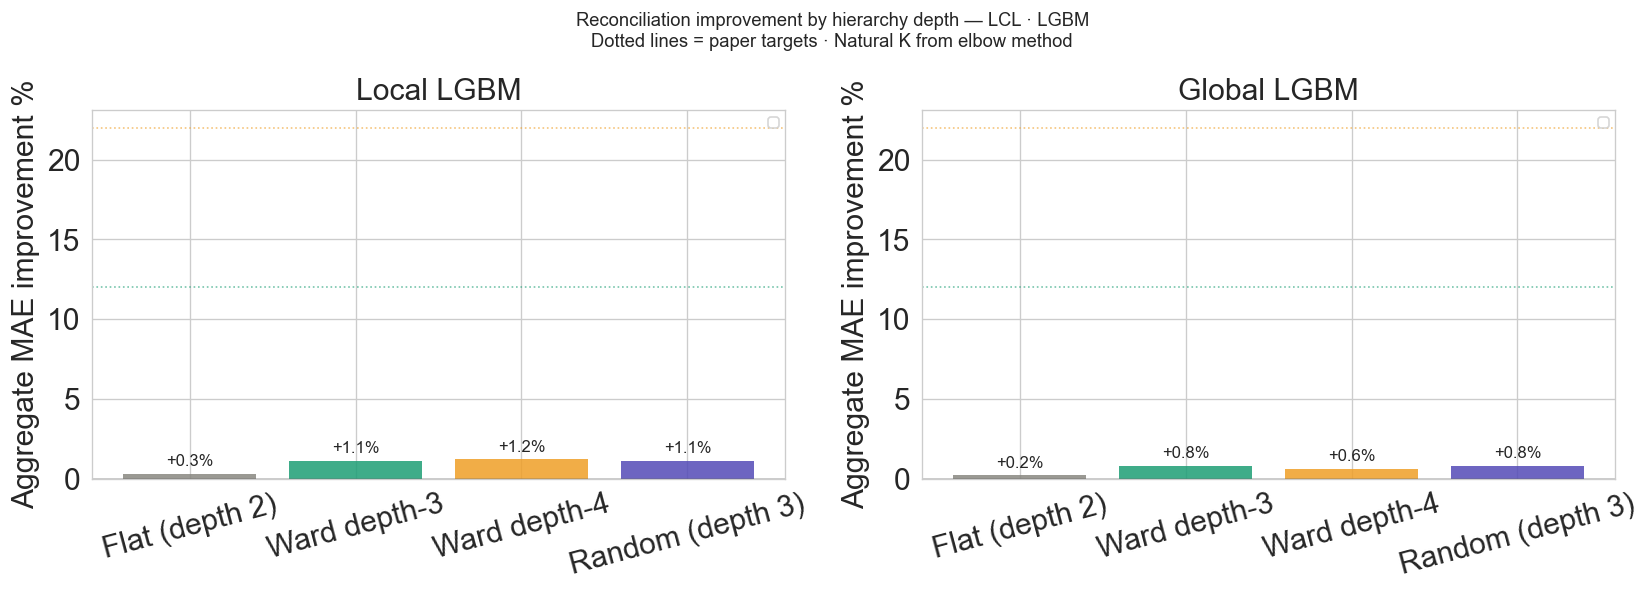

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_improvement_lcl.png


In [25]:
COLORS_METHOD = {
    'Flat (depth 2)':    '#888780',
    'Ward depth-3':      '#1D9E75',
    'Ward depth-4':      '#EF9F27',
    'Random (depth 3)':  '#534AB7',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ['local','global']):
    sub  = table1[table1['Approach']==approach]
    bars = ax.bar(
        sub['Hierarchy'],
        sub['Improvement%'],
        color=[COLORS_METHOD.get(h,'#888780') for h in sub['Hierarchy']],
        alpha=0.85, edgecolor='none'
    )
    for bar, val in zip(bars, sub['Improvement%']):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            bar.get_height()+(0.3 if val>=0 else -1.2),
            f'{val:+.1f}%', ha='center', va='bottom', fontsize=10
        )
    ax.axhline(0,  color='black', linewidth=0.8)
    ax.axhline(12, color='#1D9E75', linewidth=1, linestyle=':',
               alpha=0.6)
    ax.axhline(22, color='#EF9F27', linewidth=1, linestyle=':',
               alpha=0.6)
    ax.set_title(f'{approach.capitalize()} LGBM')
    ax.set_ylabel('Aggregate MAE improvement %')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

plt.suptitle(
    f'Reconciliation improvement by hierarchy depth — {DATASET.upper()} · LGBM\n'
    f'Dotted lines = paper targets · Natural K from elbow method',
    fontsize=11
)
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_improvement_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')

## Figure 5 — RQ1: Does clustering method matter?

In [26]:
rq1 = table1[
    (table1['Approach']=='local') &
    (table1['Hierarchy'].isin(['Ward depth-3','Random (depth 3)','Flat (depth 2)']))
][['Hierarchy','Agg MAE after','Improvement%','Bldg MAE after','MAAdj']]

ward_imp   = float(table1[(table1['Approach']=='local') &
                           (table1['Hierarchy']=='Ward depth-3')]['Improvement%'].values[0])
random_imp = float(table1[(table1['Approach']=='local') &
                           (table1['Hierarchy']=='Random (depth 3)')]['Improvement%'].values[0])
diff = abs(ward_imp - random_imp)

print('RQ1: Does clustering method matter (Ward vs Random at same depth)?')
print(rq1.to_string(index=False))
print(f'\nWard improvement   : {ward_imp:+.1f}%')
print(f'Random improvement : {random_imp:+.1f}%')
print(f'Difference         : {diff:.1f}pp')
print(f'\nConclusion: clustering method is '
      f'{"IRRELEVANT (< 1pp)" if diff < 1.0 else f"RELEVANT ({diff:.1f}pp difference)"}')

RQ1: Does clustering method matter (Ward vs Random at same depth)?
       Hierarchy  Agg MAE after  Improvement%  Bldg MAE after  MAAdj
  Flat (depth 2)          1.432           0.3           0.216 0.0269
    Ward depth-3          1.420           1.1           0.216 0.1476
Random (depth 3)          1.421           1.1           0.215 0.1394

Ward improvement   : +1.1%
Random improvement : +1.1%
Difference         : 0.0pp

Conclusion: clustering method is IRRELEVANT (< 1pp)


## Figure 6 — MAAdj ranked plot (paper Fig 5)

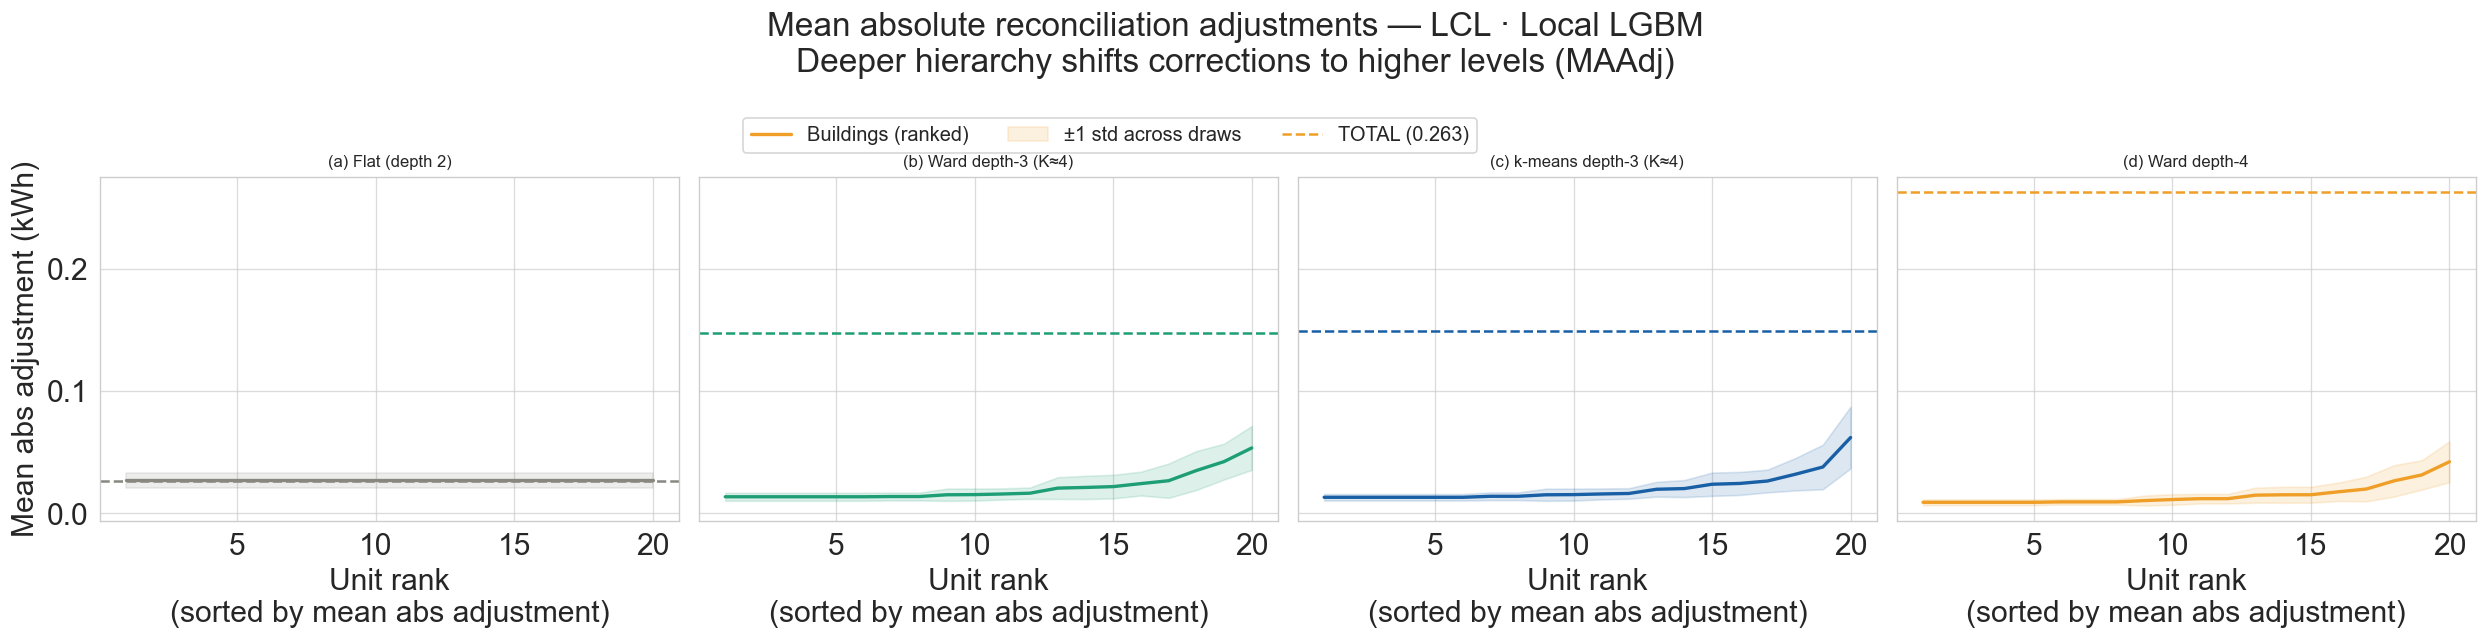

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_maadj_ranked_lcl.png


In [27]:
# ── MAAdj ranked plot — uses maadj_store_{DATASET}.parquet ────────────────────
# maadj_df columns: draw, approach, model, cluster_method, {ID}, maa
# One row per (draw, approach, model, method, unit).
# We rank buildings by mean maa across draws, then plot mean ± std at each rank.

import numpy as np

def ranked_adj_from_maadj(df, method, approach='local', model='LGBM'):
    """
    For a given method, compute the ranked building adjustment profile.
    Returns:
        ranks     : array of rank positions (1..N)
        mean_adj  : mean adjustment at each rank across draws
        std_adj   : std across draws at each rank
        total_adj : mean |adjustment| at TOTAL level (from metrics)
        cluster_adj: mean |adjustment| at cluster level (from metrics, NaN if flat)
    """
    sub = df[
        (df['cluster_method'] == method) &
        (df['approach'] == approach) &
        (df['model'] == model)
    ]
    if len(sub) == 0:
        return None

    # Per-draw: sort buildings by maa and align by rank
    draw_profiles = []
    for draw_id, grp in sub.groupby('draw'):
        sorted_vals = grp.sort_values('maa')['maa'].values
        draw_profiles.append(sorted_vals)

    # Align by rank (all draws should have same N — truncate to min if not)
    min_n = min(len(p) for p in draw_profiles)
    mat   = np.vstack([p[:min_n] for p in draw_profiles])  # (n_draws, N)

    ranks    = np.arange(1, min_n + 1)
    mean_adj = mat.mean(axis=0)
    std_adj  = mat.std(axis=0)
    return ranks, mean_adj, std_adj


def get_node_adj_from_metrics(metrics_df, method, level, approach='local', model='LGBM'):
    """Get mean MAAdj for a given node level from metrics_all."""
    mask = (
        (metrics_df['cluster_method'] == method) &
        (metrics_df['approach'] == approach) &
        (metrics_df['model'] == model) &
        (metrics_df['level'] == level)
    )
    sub = metrics_df[mask]
    return float(sub['maa'].values[0]) if len(sub) > 0 else float('nan')


all_metrics = pd.concat([metrics_flat, metrics_struct], ignore_index=True)

avail_methods = sorted(maadj_df['cluster_method'].unique())

# Always show flat + ward_depth3 + ward_depth4 if available
# Also add kmeans_depth3 for the RQ1 comparison panel
plot_configs = []
for method, label in [
    ('flat',          '(a) Flat (depth 2)'),
    ('ward_depth3',   f'(b) Ward depth-3 (K≈{k_fines[best_draw]})'),
    ('kmeans_depth3', f'(c) k-means depth-3 (K≈{k_fines[best_draw]})'),
    ('ward_depth4',   '(d) Ward depth-4'),
]:
    if method in avail_methods:
        result = ranked_adj_from_maadj(maadj_df, method)
        if result is not None:
            plot_configs.append((method, label, result))

n_panels = len(plot_configs)
fig, axes = plt.subplots(1, n_panels,
                          figsize=(5 * n_panels + 1, 5), sharey=True)
if n_panels == 1: axes = [axes]

COLORS = {
    'flat':          '#888780',
    'ward_depth3':   '#1D9E75',
    'kmeans_depth3': '#185FA5',
    'ward_depth4':   '#EF9F27',
}

for ax, (method, title, (ranks, mean_adj, std_adj)) in zip(axes, plot_configs):
    color = COLORS.get(method, '#888780')

    ax.plot(ranks, mean_adj, color=color, linewidth=2, label='Buildings (ranked)')
    ax.fill_between(ranks,
                    np.maximum(0, mean_adj - std_adj),
                    mean_adj + std_adj,
                    alpha=0.15, color=color, label='±1 std across draws')

    # TOTAL line from metrics
    total_adj = get_node_adj_from_metrics(all_metrics, method, 'aggregate')
    if np.isfinite(total_adj):
        ax.axhline(total_adj, color=color, linewidth=1.5,
                   linestyle='--', label=f'TOTAL ({total_adj:.3f})')

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Unit rank\n(sorted by mean abs adjustment)')
    if ax == axes[0]:
        ax.set_ylabel(f'Mean abs adjustment ({KWH})')
    ax.grid(True, alpha=0.7)

handles, labels = axes[-1].get_legend_handles_labels()
# deduplicate
seen = set(); uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq_h.append(h); uniq_l.append(l); seen.add(l)
fig.legend(uniq_h, uniq_l, loc='upper center', ncol=4,
           fontsize=12, bbox_to_anchor=(0.45, 0.9))

plt.suptitle(
    f'Mean absolute reconciliation adjustments — {DATASET.upper()} · Local LGBM\n'
    f'Deeper hierarchy shifts corrections to higher levels (MAAdj)',
    fontsize=20, y=1.06
)
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_maadj_ranked_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')

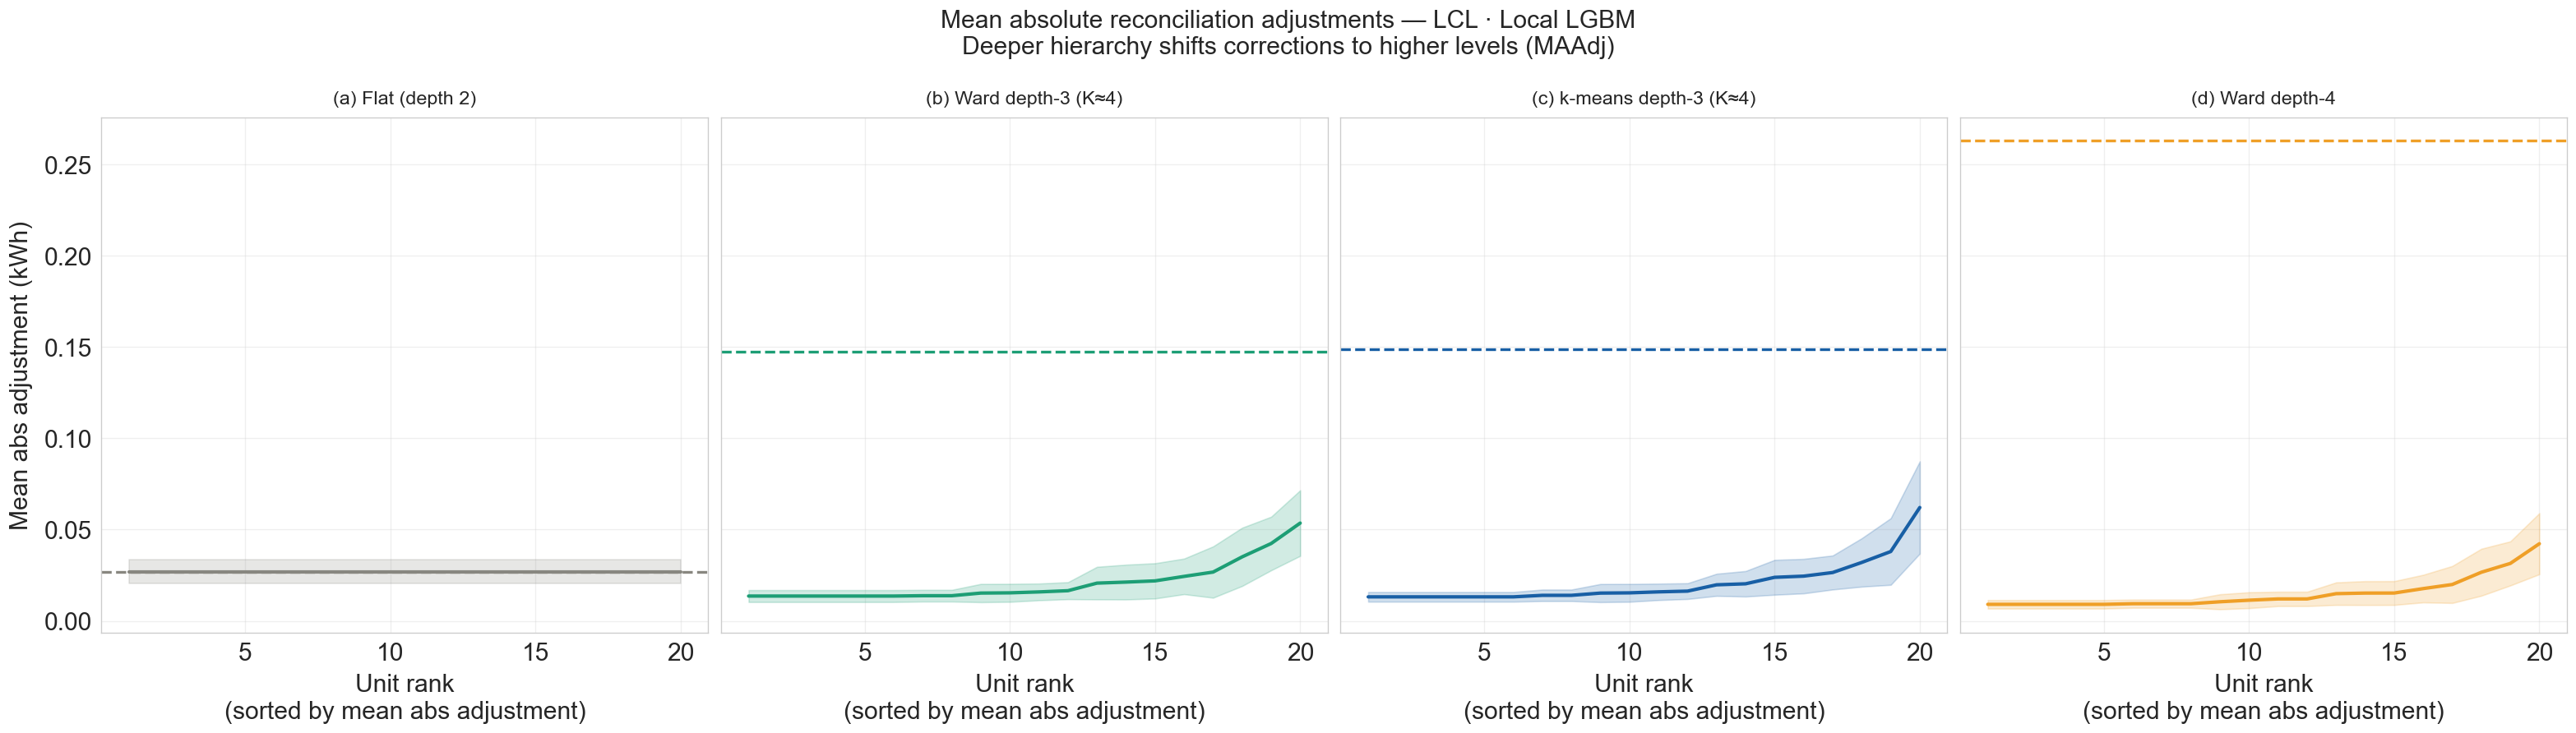

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_maadj_ranked_lcl.png


In [28]:
import matplotlib.pyplot as plt
import numpy as np

# --- GLOBAL FONT SETTINGS ---
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})

n_panels = len(plot_configs)

# --- BIGGER FIGURE + AUTO LAYOUT ---
fig, axes = plt.subplots(
    1, n_panels,
    figsize=(6.5 * n_panels, 6.5),   # bigger panels
    sharey=True,
    constrained_layout=True          # better than tight_layout
)

if n_panels == 1:
    axes = [axes]

COLORS = {
    'flat':          '#888780',
    'ward_depth3':   '#1D9E75',
    'kmeans_depth3': '#185FA5',
    'ward_depth4':   '#EF9F27',
}

for ax, (method, title, (ranks, mean_adj, std_adj)) in zip(axes, plot_configs):
    color = COLORS.get(method, '#888780')

    ax.plot(ranks, mean_adj, color=color, linewidth=2.5)
    ax.fill_between(
        ranks,
        np.maximum(0, mean_adj - std_adj),
        mean_adj + std_adj,
        alpha=0.2,
        color=color
    )

    # TOTAL line
    total_adj = get_node_adj_from_metrics(all_metrics, method, 'aggregate')
    if np.isfinite(total_adj):
        ax.axhline(
            total_adj,
            color=color,
            linewidth=2,
            linestyle='--'
        )

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Unit rank\n(sorted by mean abs adjustment)', labelpad=6)

    if ax == axes[0]:
        ax.set_ylabel(f'Mean abs adjustment ({KWH})', labelpad=8)

    ax.grid(True, alpha=0.3)

# --- CLEAN LEGEND (TOP, NO OVERLAP) ---
handles, labels = axes[-1].get_legend_handles_labels()
seen = set()
uniq_h, uniq_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        uniq_h.append(h)
        uniq_l.append(l)
        seen.add(l)

fig.legend(
    uniq_h, uniq_l,
    loc='upper center',
    ncol=3,
    fontsize=12,
    bbox_to_anchor=(0.5, 1.08),
    frameon=False
)

# --- TITLE WITH SPACE ---
fig.suptitle(
    f'Mean absolute reconciliation adjustments — {DATASET.upper()} · Local LGBM\n'
    f'Deeper hierarchy shifts corrections to higher levels (MAAdj)',
    fontsize=18,
    y=1.12
)

# --- SAVE ---
path = os.path.join(fig_dir, f'fig_maadj_ranked_{DATASET}.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved -> {path}')

## Summary

In [29]:
print('=' * 80)
print(f'CLUSTERING AND RESULTS SUMMARY — {DATASET.upper()}')
print('=' * 80)
print(f'\nClusters loaded from notebook 07 (not recomputed here)')
print(f'Random seed used in nb07 : {meta["random_seed"]}')
print(f'K method                 : {meta["k_method"]}')
print(f'W source                 : {meta["w_source"]}')
print(f'MinT formula             : {meta["mint_formula"]}')
print(f'\nDraw {best_draw} (best for visualisation):')
print(f'  K fine   = {k_fines[best_draw]}')
print(f'  K coarse = {k_coarses[best_draw]}')
print(f'  S flat   : {S_flat.shape}')
print(f'  S depth3 : {S_d3.shape}')
print(f'  S depth4 : {S_d4.shape}')
print(f'\nReconciliation — global LGBM:')
for _, row in table1[table1['Approach']=='local'].iterrows():
    arrow = 'IMPROVED' if row['Improvement%'] > 0 else 'DEGRADED'
    print(f'  {row["Hierarchy"]:22}: {row["Improvement%"]:+.1f}% agg MAE  [{arrow}]')
print(f'\nPaper targets: flat ~1-2% | depth-3 ~12% | depth-4 ~22%')
print(f'Ward vs Random: {diff:.1f}pp difference -> '
      f'{"clustering method IRRELEVANT" if diff<1 else "clustering method MATTERS"}')

CLUSTERING AND RESULTS SUMMARY — LCL

Clusters loaded from notebook 07 (not recomputed here)
Random seed used in nb07 : 42
K method                 : natural elbow — second difference of Ward linkage distances
W source                 : val period residual variances (no test data leakage)
MinT formula             : W_full = S @ Wb @ S.T  (structural WLS)

Draw 7 (best for visualisation):
  K fine   = 4
  K coarse = 2
  S flat   : (21, 20)
  S depth3 : (25, 20)
  S depth4 : (27, 20)

Reconciliation — global LGBM:
  Flat (depth 2)        : +0.3% agg MAE  [IMPROVED]
  Ward depth-3          : +1.1% agg MAE  [IMPROVED]
  Ward depth-4          : +1.2% agg MAE  [IMPROVED]
  Random (depth 3)      : +1.1% agg MAE  [IMPROVED]

Paper targets: flat ~1-2% | depth-3 ~12% | depth-4 ~22%
Ward vs Random: 0.0pp difference -> clustering method IRRELEVANT


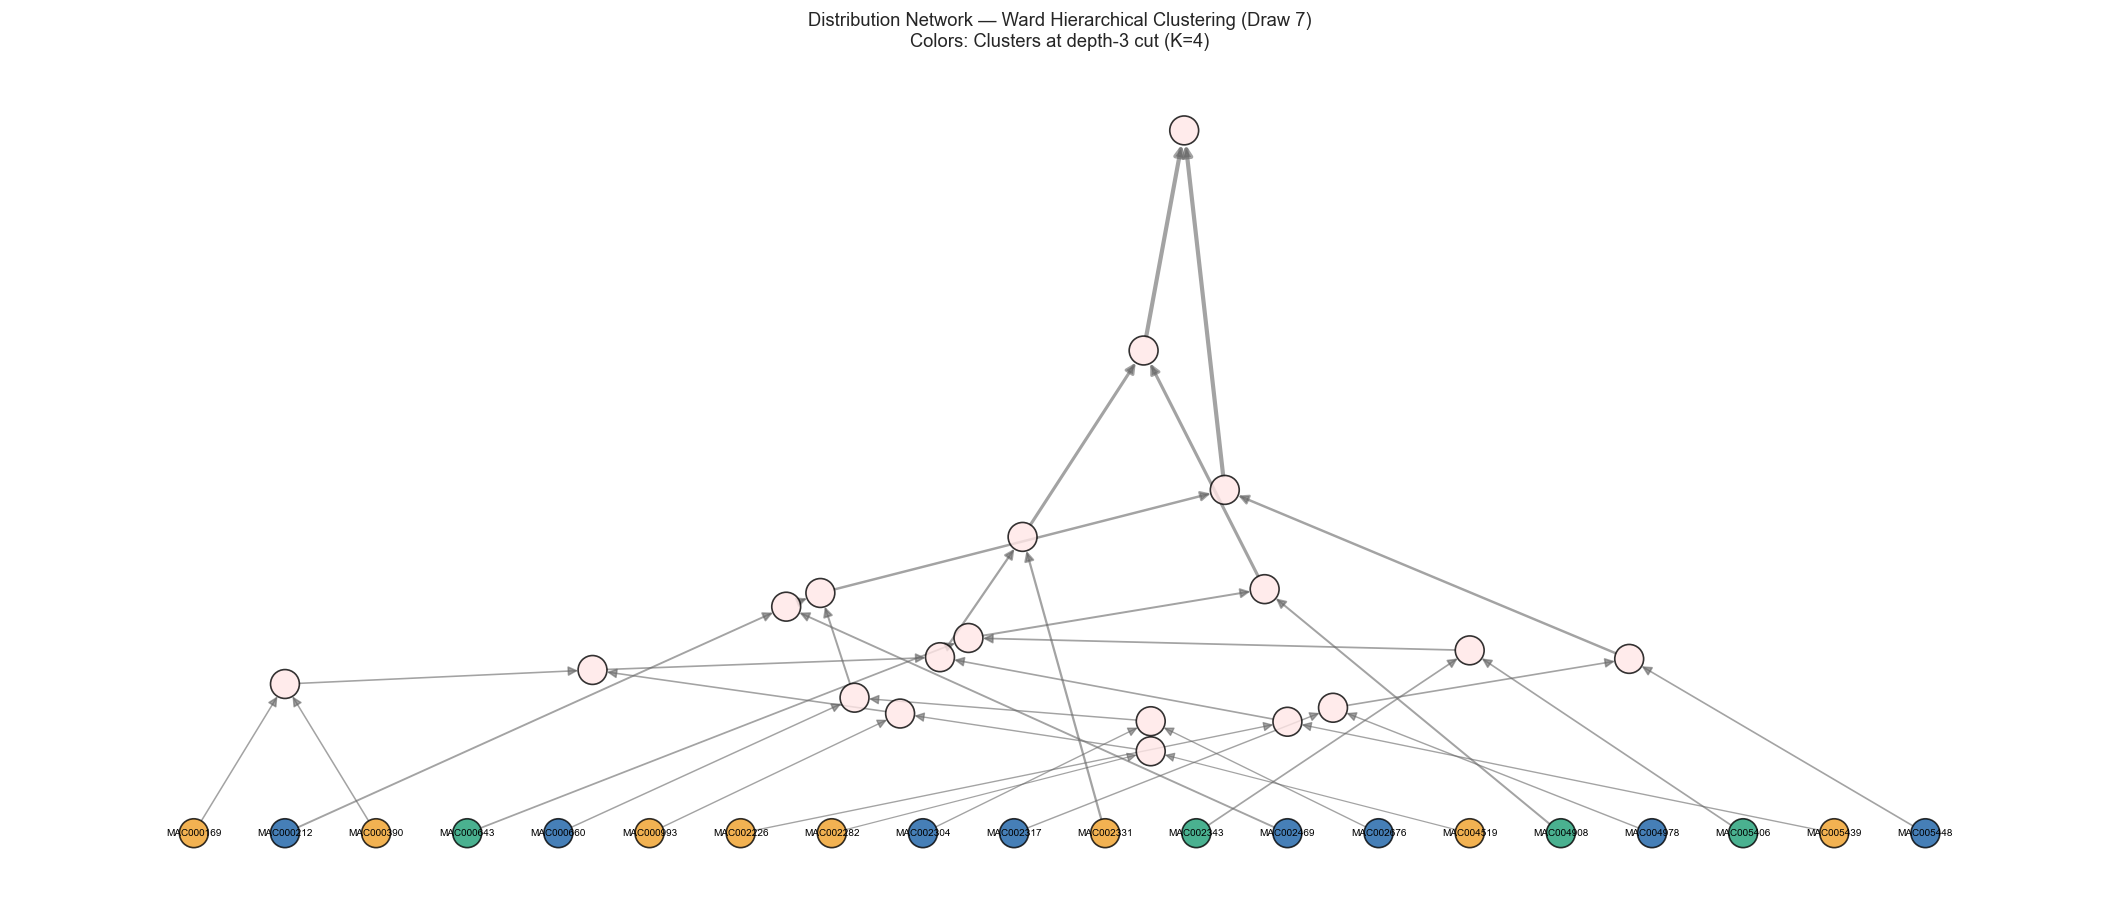

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_network_dendro_lcl.png


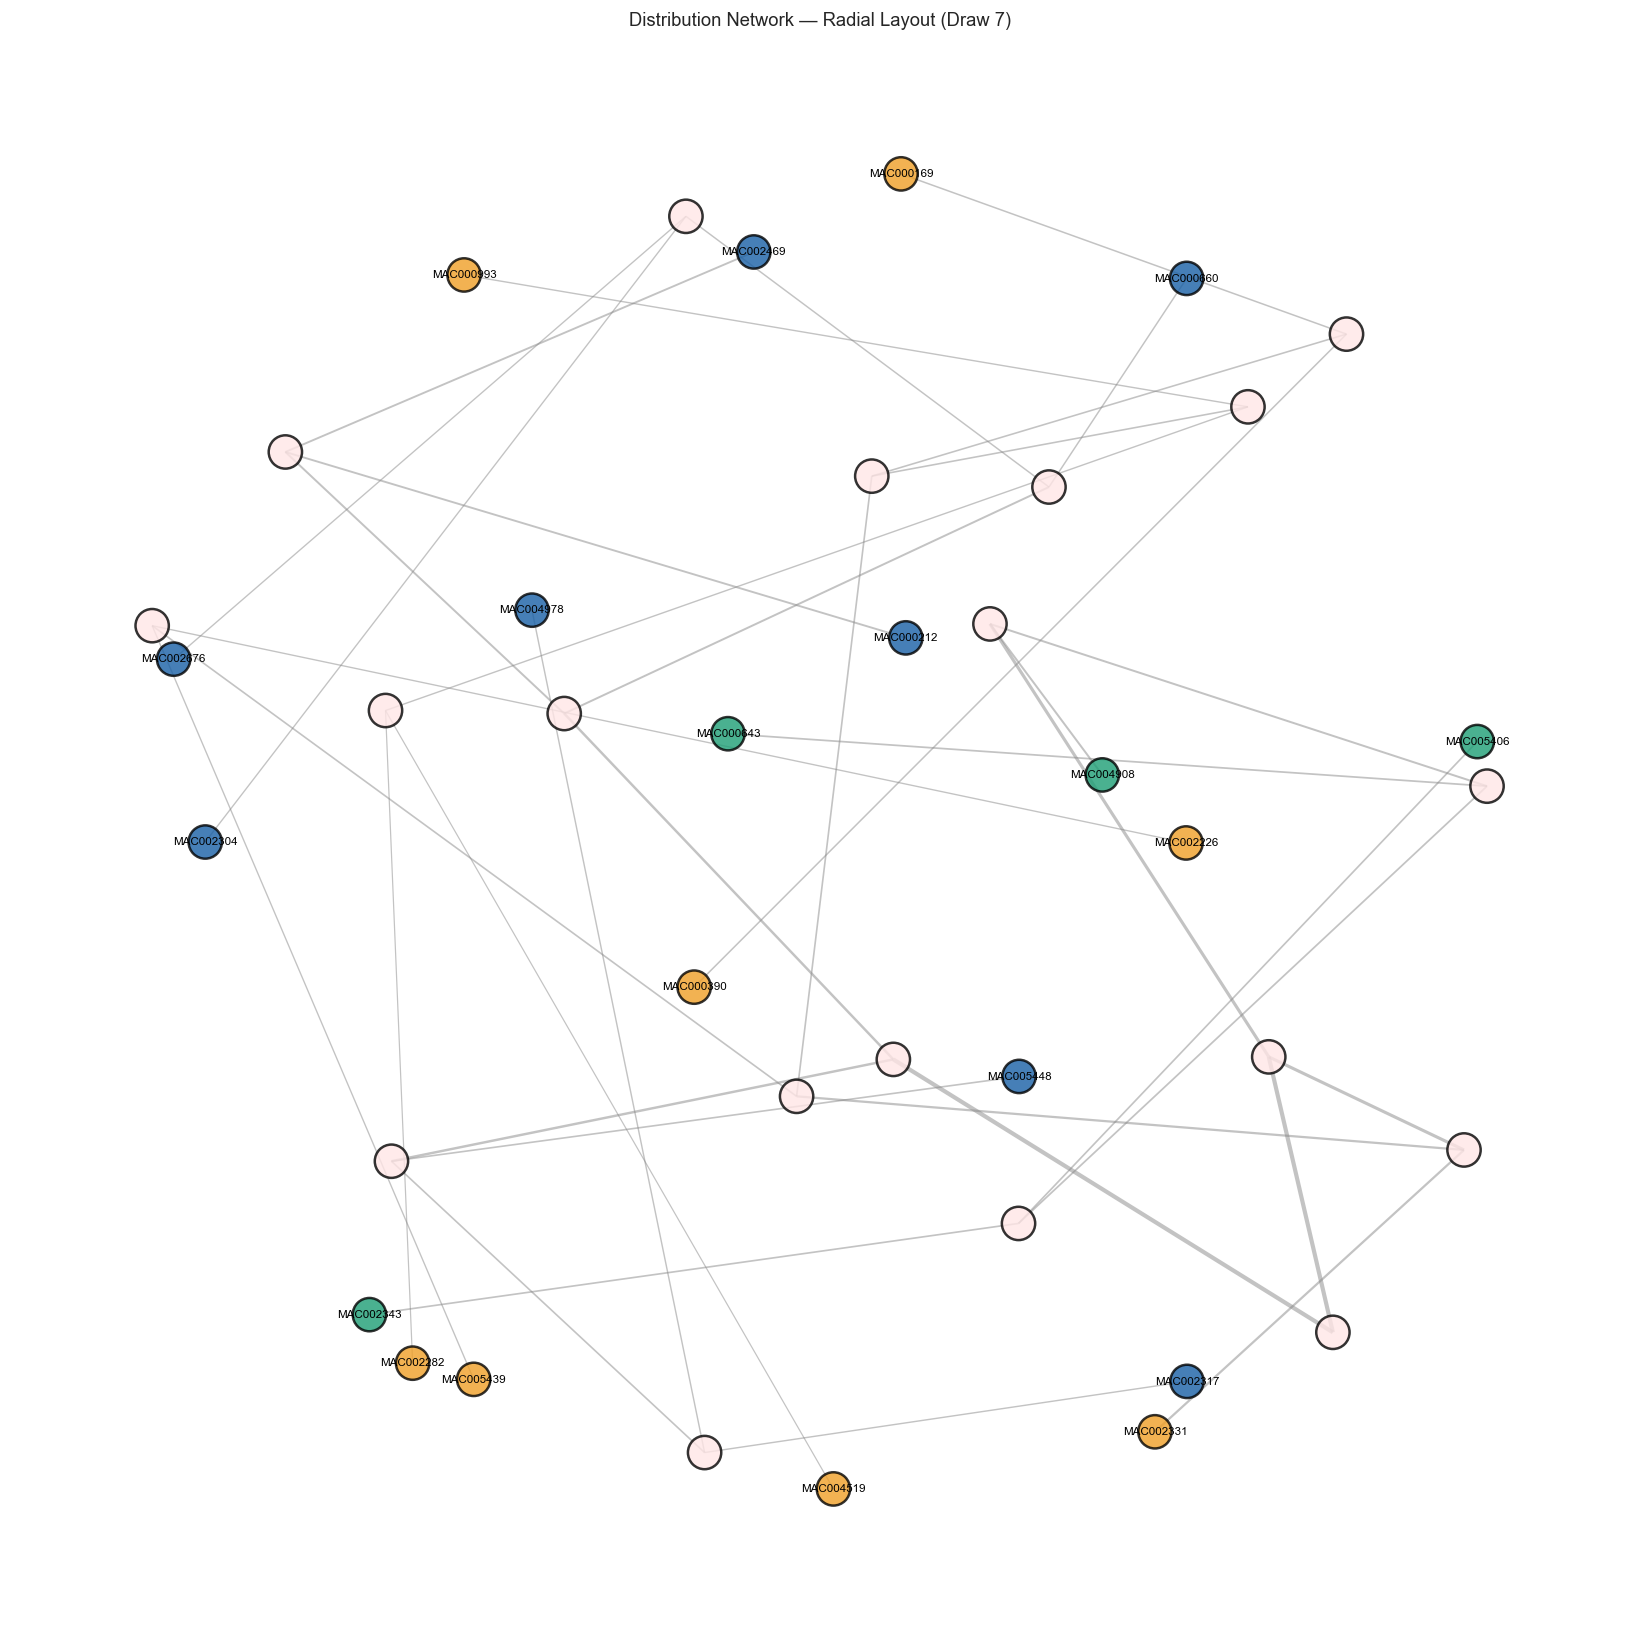

Saved -> /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/results/figures/fig_network_radial_lcl.png

Network Statistics:
  Total nodes: 39
    - Leaf nodes (units): 20
    - Internal cluster nodes: 19
  Total edges: 38
  Network depth (max height): 20.50
  Clusters at fine cut: 4


In [30]:
"""
To add to notebook 08 after the dendrogram section (after cell with Z_draw definition).

This cell plots the Ward hierarchical clustering as a NetworkX distribution network diagram
alongside or instead of the scipy dendrogram.
"""

# ============================================================================
# CELL: Plot dendrogram as NetworkX distribution network
# ============================================================================

import networkx as nx

def linkage_to_network(Z, labels=None, cut_height=None):
    """Convert scipy linkage matrix to NetworkX DiGraph hierarchy."""
    n_leaves = Z.shape[0] + 1
    
    if labels is None:
        labels = [str(i) for i in range(n_leaves)]
    
    G = nx.DiGraph()
    
    # Add leaf nodes
    for i in range(n_leaves):
        G.add_node(i, label=labels[i], is_leaf=True, height=0)
    
    # Process linkage to build internal nodes
    for step, (idx1, idx2, distance, num_samples) in enumerate(Z):
        cluster_id = n_leaves + step
        
        G.add_node(
            cluster_id,
            label=f"C{step}",
            is_leaf=False,
            height=distance,
            size=int(num_samples)
        )
        
        idx1, idx2 = int(idx1), int(idx2)
        G.add_edge(idx1, cluster_id, weight=distance)
        G.add_edge(idx2, cluster_id, weight=distance)
    
    return G


def compute_hierarchy_layout(G):
    """Compute hierarchical layout: leaves at bottom, root at top."""
    pos = {}
    
    for node in G.nodes():
        if G.nodes[node]['is_leaf']:
            pos[node] = (node, 0)
        else:
            children = list(G.predecessors(node))
            if children:
                child_xs = [pos[c][0] for c in children if c in pos]
                if child_xs:
                    x = np.mean(child_xs)
                    y = G.nodes[node]['height']
                    pos[node] = (x, y)
    
    return pos


# Build network from Z_draw
G = linkage_to_network(Z_draw, labels=[str(u) for u in draw_units])
pos = compute_hierarchy_layout(G)

# Assign cluster colors based on fine cut
cluster_assignment = fcluster(Z_draw, h_fine, criterion='distance')
cluster_colors_map = {
    1: '#185FA5',  # Blue
    2: '#1D9E75',  # Green
    3: '#EF9F27',  # Orange
}
node_colors = [
    cluster_colors_map.get(cluster_assignment[n], '#cccccc') 
    if G.nodes[n]['is_leaf']
    else '#ffe6e6'
    for n in G.nodes()
]

# Create figure
fig_net, ax_net = plt.subplots(figsize=(18, 8))

# Draw network
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=300,
    ax=ax_net,
    alpha=0.8,
    edgecolors='black',
    linewidths=1
)

# Draw edges with widths based on distance
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
max_weight = max(edge_weights) if edge_weights else 1
edge_widths = [0.5 + 2 * (w / max_weight) for w in edge_weights]

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color='#666666',
    ax=ax_net,
    alpha=0.6,
    arrows=True,
    arrowsize=12,
    arrowstyle='-|>'
)

# Draw labels for leaf nodes only
leaf_labels = {n: G.nodes[n]['label'] 
               for n in G.nodes() if G.nodes[n]['is_leaf']}
nx.draw_networkx_labels(
    G, pos,
    labels=leaf_labels,
    font_size=6,
    ax=ax_net
)

ax_net.set_title(
    f"Distribution Network — Ward Hierarchical Clustering (Draw {best_draw})\n"
    f"Colors: Clusters at depth-3 cut (K={k_fine})",
    fontsize=11
)
ax_net.axis('off')
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_network_dendro_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')


# ============================================================================
# Alternative: Circular/Radial layout (better for complex trees)
# ============================================================================

# Use spring layout for radial appearance
pos_radial = nx.spring_layout(G, k=3, iterations=100, seed=42)

fig_rad, ax_rad = plt.subplots(figsize=(14, 14))

nx.draw_networkx_nodes(
    G, pos_radial,
    node_color=node_colors,
    node_size=400,
    ax=ax_rad,
    alpha=0.8,
    edgecolors='black',
    linewidths=1.5
)

nx.draw_networkx_edges(
    G, pos_radial,
    width=edge_widths,
    edge_color='#888888',
    ax=ax_rad,
    alpha=0.5,
    arrows=False
)

nx.draw_networkx_labels(
    G, pos_radial,
    labels=leaf_labels,
    font_size=7,
    ax=ax_rad
)

ax_rad.set_title(
    f"Distribution Network — Radial Layout (Draw {best_draw})",
    fontsize=11
)
ax_rad.axis('off')
plt.tight_layout()
path = os.path.join(fig_dir, f'fig_network_radial_{DATASET}.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {path}')


# ============================================================================
# Print network statistics
# ============================================================================

print("\nNetwork Statistics:")
print(f"  Total nodes: {G.number_of_nodes()}")
print(f"    - Leaf nodes (units): {sum(1 for n in G.nodes() if G.nodes[n]['is_leaf'])}")
print(f"    - Internal cluster nodes: {sum(1 for n in G.nodes() if not G.nodes[n]['is_leaf'])}")
print(f"  Total edges: {G.number_of_edges()}")
print(f"  Network depth (max height): {max(G.nodes[n]['height'] for n in G.nodes() if not G.nodes[n]['is_leaf']):.2f}")
print(f"  Clusters at fine cut: {k_fine}")